In [1]:
import scanpy as sc

In [2]:
def run_leiden_clustering(
    adata: sc.AnnData,
    resolution: float = 0.6,
    key_added: str = "leiden"
) -> sc.AnnData:
    """
    Run Leiden clustering on the neighbour graph.
    This detects clusters of cells with similar transcriptional profiles, based on previously computed k-nearest neighbour graph.
    -----------
    Parameters
    -----------
        adata: AnnData object. Must contain a neighbour graph in:
            - adata.obsp["connectivities"]
            - adata.uns["neighbors"]
        resolution: Clustering resolution. Higher values produce more clusters.
        key_added: Name of the column in 'adata.obs' used to store Leiden cluster labels.
    --------
    Returns
    --------
        adata: AnnData object, updated with adata.obs[key_added]
    """
    if "neighbors" not in adata.uns:
        raise KeyError(
            "'neighbors' not found in adata.uns. "
            "Please run build_neighbor_graph() first."
        )
    
    sc.tl.leiden(
        adata,
        resolution = resolution,
        key_added = key_added
    )

    n_clusters = adata.obs[key_added].nunique()

    print(
        f"Leiden clustering complete.\n"
        f"Resolution used: {resolution}\n"
        f"Cluster labels stored in: adata.obs['{key_added}']\n"
        f"Number of clusters detected: {n_clusters}"
    )

    return adata

In [3]:
def find_cluster_markers(
    adata: sc.AnnData,
    groupby: str = "leiden",
    method: str = "wilcoxon",
    key_added: str = "rank_genes_groups",
    use_raw: bool = False,
    layer: str | None = "log1p_normalized_counts"
) -> sc.AnnData:
    """
    Identify marker genes for each cluster.
    This compares each cluster against all other cells to find genes that are specifically enriched in that cluster.
    -----------
    Parameters
    -----------
        adata: AnnData object. Must contain cluster labels in adata.obs[groupby].
        groupby: Column in `adata.obs` containing cluster assignments.
        method: Statistical test used for marker detection.
        key_added: Name under which results will be stored in `adata.uns`.
        use_raw: Whether to use 'adata.raw; as the input.
        layer: Layer to use for marker testing if 'use_raw = False'. Set to None to use 'adata.X'.
    --------
    Returns
    --------
        adata: AnnData object, updated with:
            - adata.uns[key_added]
    """
    if groupby not in adata.obs.columns:
        raise KeyError(
            f"'{groupby}' not found in adata.obs. "
            "Please run run_leiden_clustering() first or specify a valid grouping column."
        )
    
    if layer is not None and layer not in adata.layers:
        raise KeyError(
            f"'{layer}' not found in adata.layers. "
            "Please specify a valid input layer or set layer=None to use adata.X."
        )
    
    sc.tl.rank_genes_groups(
        adata,
        groupby = groupby,
        method = method, 
        key_added = key_added,
        use_raw = use_raw,
        layer = layer
    )

    print(
        f"Cluster marker detection complete.\n"
        f"Grouping column used: adata.obs['{groupby}']\n"
        f"Statistical method: {method}\n"
        f"Results stored in: adata.uns['{key_added}']"
    )
    
    return adata


In [4]:
def annotate_cell_types(
    adata: sc.AnnData,
    cluster_key: str = "leiden",
    annotation_dict: dict | None = None,
    output_key: str = "cell_type",
    undefined_type: str = "Undefined"
) -> sc.AnnData:
    """
    Annotate clusters with biological cell type labels.
    This function maps cluster labels (e.g., Leiden clusters) to user-defined biological identities.
    -----------
    Parameters
    -----------
        adata: AnnData object. Must contain cluster labels in adata.obs[cluster_key].
        cluster_key: Column in `adata.obs` containing cluster assignments.
        annotation_dict: Dictionary mapping cluster labels to cell type names.
                         Example:
                             {"0": "Excitatory neurons", "1": "Astrocytes", "2": "Microglia"}
        output_key: Name of the new column in `adata.obs` used to store cell type labels.
        undefined_type: Label assigned to clusters not found in 'annotation_dict'.
    --------
    Returns
    --------
        adata: AnnData object, updated with adata.obs[output_key]
    """
    if cluster_key not in adata.obs.columns:
        raise KeyError(
            f"'{cluster_key}' not found in adata.obs. "
            "Please run run_leiden_clustering() first or specify a valid cluster key."
        )

    if annotation_dict is None:
        raise ValueError(
            "annotation_dict must be provided. "
            "Example: {'0': 'Excitatory neurons', '1': 'Astrocytes'}"
        )

    adata.obs[output_key] = (
        adata.obs[cluster_key]
        .astype(str)
        .map(annotation_dict)
        .fillna(undefined_type)
    )

    n_cell_types = adata.obs[output_key].nunique()
    
    print(
        f"Cell type annotation complete.\n"
        f"Cluster labels read from: adata.obs['{cluster_key}']\n"
        f"Cell type labels stored in: adata.obs['{output_key}']\n"
        f"Number of unique annotations assigned: {n_cell_types}"
    )

    return adata

Below is the C9ALS sample going through the pipeline.

In [2]:
adata_dir = "../data/processed"
adata_als_scaled = sc.read_h5ad(f"{adata_dir}/c9ALS_GSM5292146_dimensionality_reduced.h5ad")

In [7]:
adata_als_scaled = run_leiden_clustering(adata_als_scaled)

Leiden clustering complete.
Resolution used: 0.6
Cluster labels stored in: adata.obs['leiden']
Number of clusters detected: 21


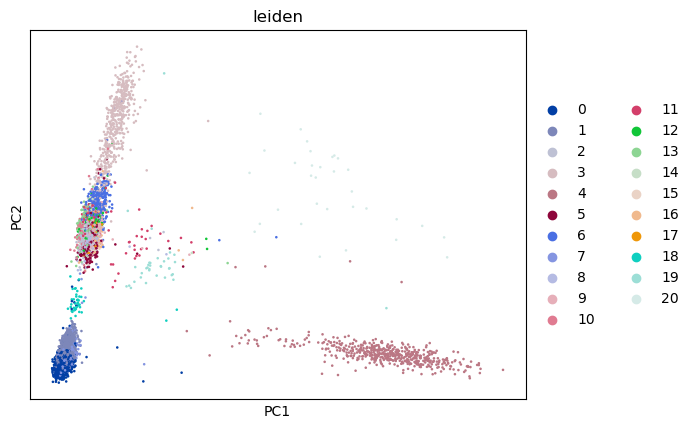

In [9]:
sc.pl.pca(
    adata_als_scaled,
    color=["leiden"],
    components="1,2"
)

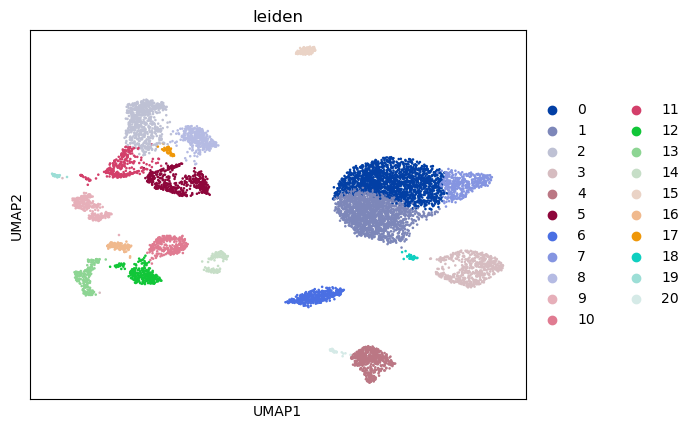

In [17]:
sc.pl.umap(adata_als_scaled, color = ["leiden"])

In [12]:
adata_als_scaled = find_cluster_markers(adata_als_scaled)

Cluster marker detection complete.
Grouping column used: adata.obs['leiden']
Statistical method: wilcoxon
Results stored in: adata.uns['rank_genes_groups']


/opt/anaconda3/envs/c9_multiomics/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:458: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "names"] = self.var_names[global_indices]
/opt/anaconda3/envs/c9_multiomics/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:460: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, "scores"] = scores[global_indices]
/opt/anaconda3/envs/c9_multiomics/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:463: Performanc

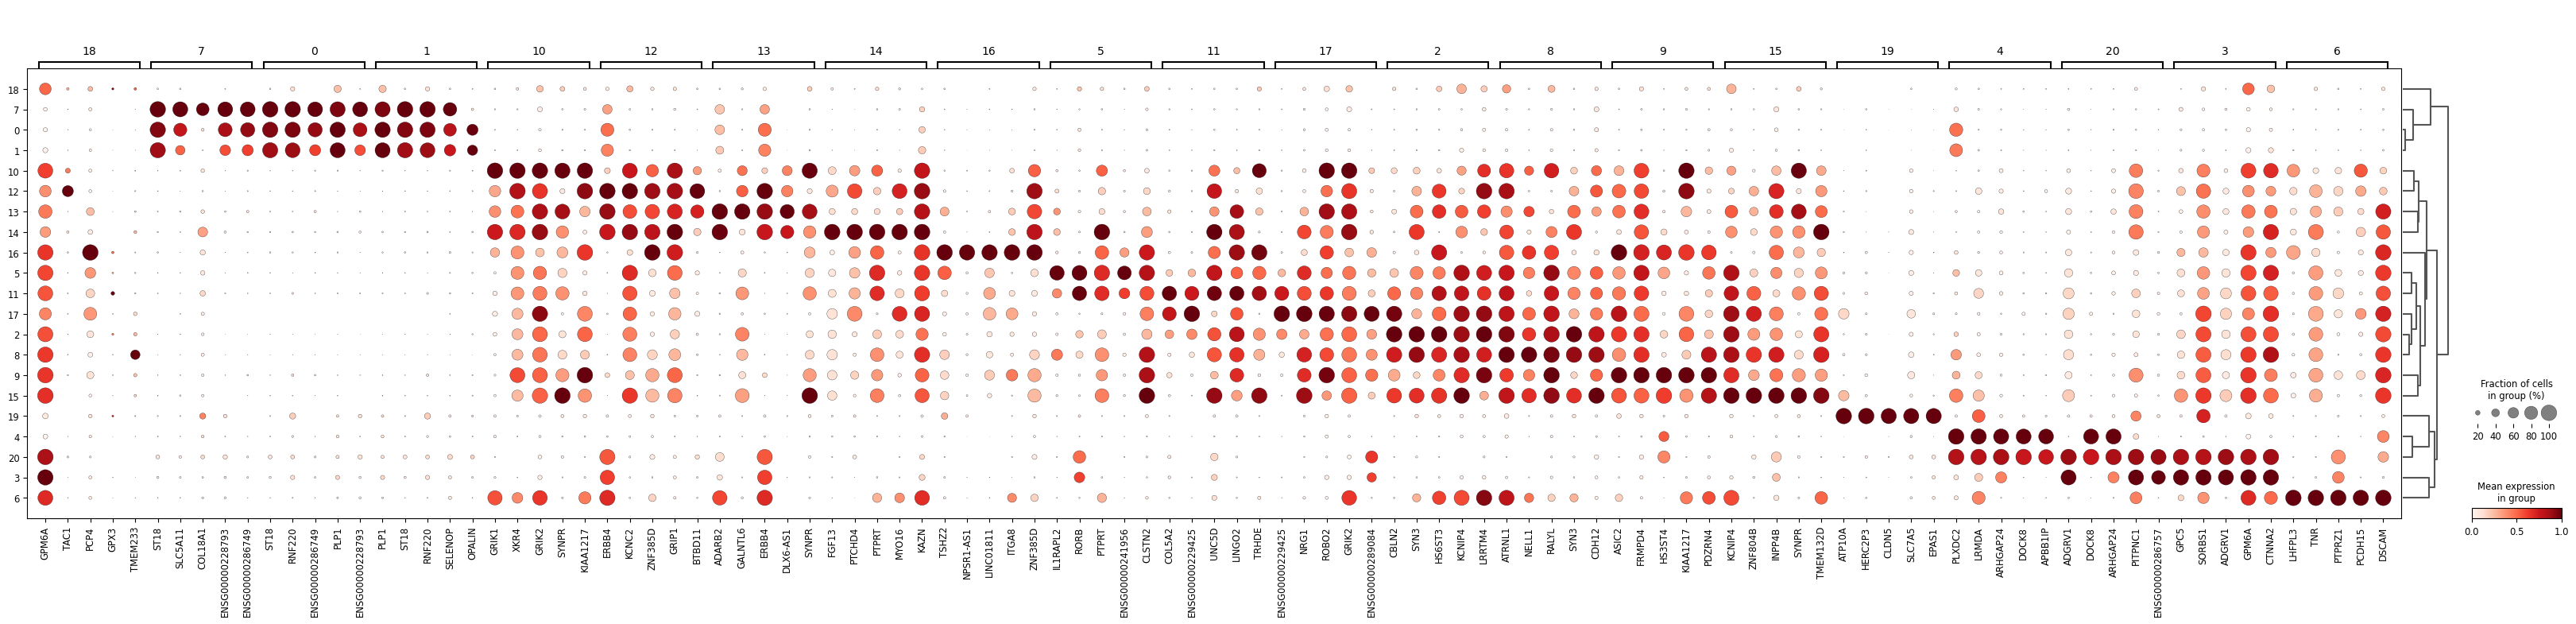

In [14]:
sc.pl.rank_genes_groups_dotplot(
    adata_als_scaled,
    groupby = "leiden",
    n_genes = 5,
    standard_scale = "var",
    key = "rank_genes_groups",
    use_raw = False
)